In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [2]:
# Load dataset
df = pd.read_csv("../data/sales_data.csv")

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Sort data
df = df.sort_values("date")

# Display first rows
df.head()

,date,sales
0,2021-01-01,104.97
1,2021-01-02,102.94
2,2021-01-03,114.95
3,2021-01-04,127.49
4,2021-01-05,113.19


In [3]:
# Dataset structure
df.info()

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1200 non-null   datetime64[ns]
 1   sales   1200 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 18.9 KB


,date,sales
count,1200,1200.000000
mean,2022-08-23 12:00:00,200.383667
min,2021-01-01 00:00:00,69.700000
25%,2021-10-27 18:00:00,150.925000
50%,2022-08-23 12:00:00,200.310000
75%,2023-06-19 06:00:00,250.547500
max,2024-04-14 00:00:00,329.210000
std,NaN,60.529019


In [4]:
# Check missing values
df.isnull().sum()

date     0
sales    0
dtype: int64

In [5]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

df.head()

,date,sales,year,month,day
0,2021-01-01,104.97,2021,1,1
1,2021-01-02,102.94,2021,1,2
2,2021-01-03,114.95,2021,1,3
3,2021-01-04,127.49,2021,1,4
4,2021-01-05,113.19,2021,1,5


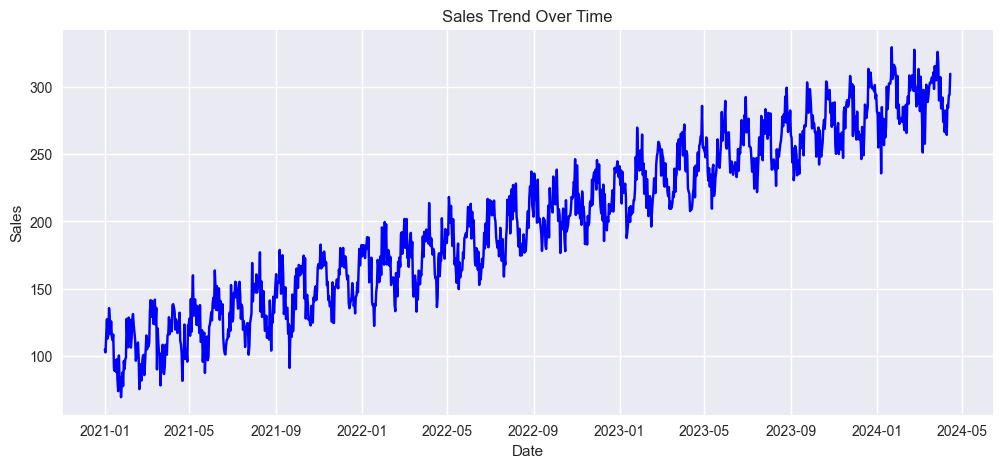

In [6]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["sales"], color="blue")

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

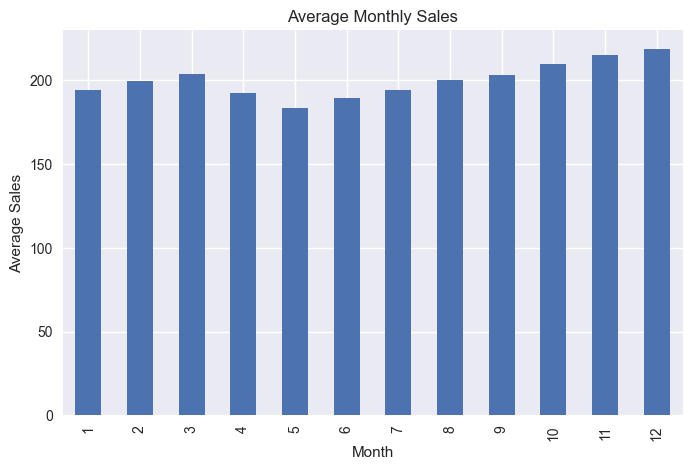

In [7]:
monthly_sales = df.groupby("month")["sales"].mean()

plt.figure(figsize=(8,5))

monthly_sales.plot(kind="bar")

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

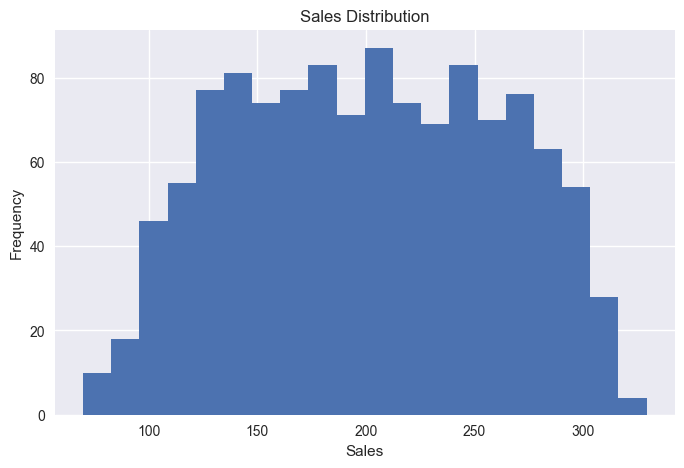

In [8]:
plt.figure(figsize=(8,5))

plt.hist(df["sales"], bins=20)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

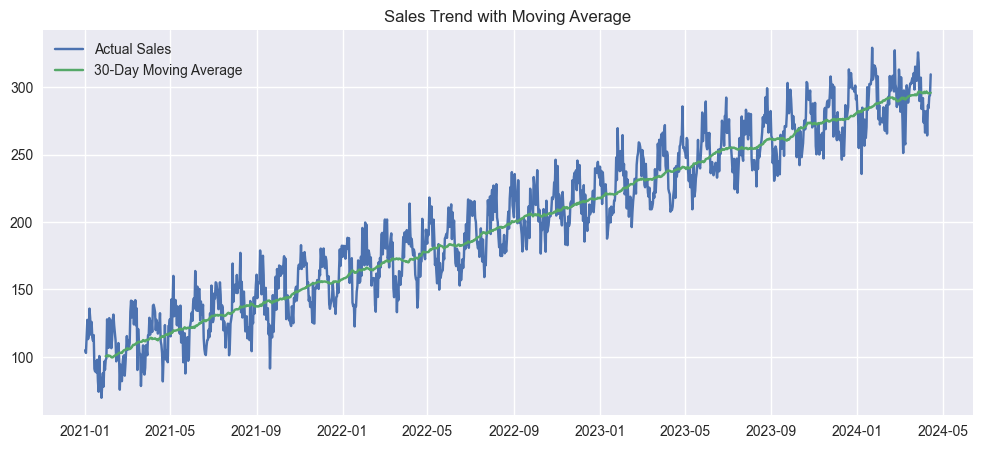

In [9]:
df["moving_avg"] = df["sales"].rolling(window=30).mean()

plt.figure(figsize=(12,5))

plt.plot(df["date"], df["sales"], label="Actual Sales")
plt.plot(df["date"], df["moving_avg"], label="30-Day Moving Average")

plt.title("Sales Trend with Moving Average")

plt.legend()

plt.show()

In [10]:
correlation = df[["sales","month","day"]].corr()

print(correlation)

          sales     month       day
sales  1.000000  0.104617  0.000229
month  0.104617  1.000000  0.017696
day    0.000229  0.017696  1.000000


In [11]:
import pandas as pd

def save_forecast_results(forecast_df):

    forecast_df.to_csv(
        "outputs/forecast_results.csv",
        index_label="date"
    )

    print("forecast_results.csv saved successfully")